# Hot_Cloudy_days

In [ ]:
rm(list=ls())
gc()

          used (Mb) gc trigger (Mb) max used (Mb)
Ncells  571028 30.5    1301308 69.5   660400 35.3
Vcells 1035387  7.9    8388608 64.0  1815182 13.9

In [ ]:
library(lubridate)
library(ggplot2)
library(tidyverse)

## Hot and Cloudy days identified using three different methods

In [ ]:
# Load hot and cloudy days identified by Sanaa, Carl and Andrew

sanaa <- read.csv("/g/data/fy29/sho561/Hot_Cloudy/processed_csv/event_dates_csi0p5_thourly90.csv")
sanaa$X <- NULL
sanaa$sanaa <- 1
carl <- read.csv(""/g/data/ng72/ab4502/hot-cloudy/data/event_dates_csi0p5_tmax90.csv"")
carl$X <- NULL
carl$carl <- 1
andrew <- read.csv("/g/data/ng72/ab4502/hot-cloudy/data/event_dates_csi0p5_tmax90.csv")
andrew$X <- NULL
andrew$andrew <- 1

# Merge by "time" and "region"
merged_df <- Reduce(function(x, y) merge(x, y, by = c("time", "region"), all = TRUE),
                    list(sanaa, carl, andrew))

# View result
head(merged_df)

write.csv(merged_df,"/g/data/fy29/sho561/Hot_Cloudy/processed_csv/event_dates_csi0p5_tmax90_carl_andrew_sanaa.csv" )

        time region sanaa carl andrew
1 2015-11-01   GHOB     1   NA     NA
2 2015-11-09   GHOB     1   NA     NA
3 2015-11-25   GADE     1   NA     NA
4 2015-11-25   GMEL     1   NA      1
5 2015-12-07   GADE     1   NA     NA
6 2015-12-07   GMEL     1   NA     NA

In [ ]:
# long: time(Date), region, who ∈ {sanaa,carl,andrew}
sanaa_k  <- sanaa  %>% transmute(time = as.Date(time), region, who = "sanaa")
carl_k   <- carl   %>% transmute(time = as.Date(time), region, who = "carl")
andrew_k <- andrew %>% transmute(time = as.Date(time), region, who = "andrew")
long <- bind_rows(sanaa_k, carl_k, andrew_k) %>%
  mutate(who = factor(who, levels = c("sanaa","carl","andrew"))) %>%
  distinct()

plot_region_cut_calendar <- function(r, gap_days = 1) {
  df0 <- long %>%
    filter(region == r) %>%
    mutate(year = year(time), month = month(time)) %>%
    filter(month %in% c(1,2,3,4,11,12))

  # Calendar-based compression: offsets inside blocks Jan–Apr and Nov–Dec
  df <- df0 %>%
    group_by(year) %>%
    mutate(
      jan_start   = as.Date(sprintf("%d-01-01", year)),
      apr_end     = as.Date(sprintf("%d-04-30", year)),
      nov_start   = as.Date(sprintf("%d-11-01", year)),
      len_JFMA    = as.integer(apr_end - jan_start) + 1,                 # 120 or 121 in leap years
      len_ND_cal  = as.integer(as.Date(sprintf("%d-12-31", year)) - nov_start) + 1, # 61
      has_ND      = any(month %in% c(11,12)),
      display_x = case_when(
        month %in% 1:4       ~ as.integer(time - jan_start) + 1,
        month %in% c(11,12)  ~ len_JFMA + if_else(has_ND, gap_days, 0L) + as.integer(time - nov_start) + 1
      )
    ) %>%
    ungroup()

  # Panel limits (no dead space; if no ND events that year, stop at Apr)
  limits <- df %>%
    distinct(year, len_JFMA, len_ND_cal, has_ND) %>%
    mutate(
      x_min = 1L,
      x_max = len_JFMA + if_else(has_ND, gap_days + len_ND_cal, 0L)
    )

  # Baselines: draw Jan–Apr always; Nov–Dec only if that year has ND events
  baselines <- bind_rows(
    limits %>% transmute(year, x1 = 1L, x2 = len_JFMA),
    limits %>% filter(has_ND) %>%
      transmute(year,
                x1 = len_JFMA + gap_days,
                x2 = len_JFMA + gap_days + len_ND_cal)
  )

  # Labels at event dates only
  ticks <- df %>% arrange(year, display_x, who) %>% distinct(year, display_x, time)

  # Points to lock per-facet limits exactly [x_min, x_max]
  limits_pts <- limits %>%
    select(year, x_min, x_max) %>%
    pivot_longer(c(x_min, x_max), names_to = "which", values_to = "x") %>%
    mutate(y = 0)

  ggplot() +
    geom_blank(data = limits_pts, aes(x = x, y = y)) +
    geom_segment(data = baselines, aes(x = x1, xend = x2, y = 0, yend = 0),
                 linewidth = 0.6, colour = "grey55") +

    # legend driver: map colour+shape once
    geom_point(data = df, aes(x = display_x, y = 0, colour = who, shape = who),
               alpha = 0, size = 2.6, stroke = 1.2, show.legend = TRUE) +

    # marks
    geom_linerange(data = df %>% filter(who == "sanaa"),
                   aes(x = display_x, ymin = -0.5, ymax = 0.5, colour = who),
                   linewidth = 1.8) +
    geom_point(data = df %>% filter(who == "carl"),
               aes(x = display_x, y = 0, colour = who),
               shape = 19, size = 4, stroke = 1.0) +
    geom_point(data = df %>% filter(who == "andrew"),
               aes(x = display_x, y = 0, colour = who),
               shape = 4, size = 3.2, stroke = 1.5) +

    geom_text(data = ticks,
              aes(x = display_x, y = -0.55, label = format(time, "%d %b")),
              angle = 90, vjust = 0.5, hjust = 1, size = 2.7) +

    facet_wrap(~ year, ncol = 1, scales = "free_x") +
    scale_colour_manual(values = c(sanaa = "gold", carl = "red", andrew = "darkblue"),
                        breaks = c("sanaa","carl","andrew"), name = NULL) +
    scale_shape_manual(values = c(sanaa = 124, carl = 16, andrew = 4),
                       breaks = c("sanaa","carl","andrew"), name = NULL) +
    scale_x_continuous(expand = c(0,0)) +
    scale_y_continuous(NULL, breaks = NULL, limits = c(-0.65, 0.7)) +
    coord_cartesian(clip = "off") +
    labs(title = r, x = "Date", subtitle = "Hot-Cloudy days") +
    guides(colour = guide_legend(override.aes = list(alpha = 1, size = 3.0, stroke = 1.3)),
           shape  = guide_legend(override.aes = list(alpha = 1, size = 3.0, stroke = 1.3))) +
    theme_minimal(base_size = 10) +
    theme(panel.grid = element_blank(),
          strip.text = element_text(face = "bold"),
          axis.text.x = element_blank(),
          axis.ticks.x = element_blank(),
          legend.position = "bottom",
          legend.title = element_blank(),
          plot.margin = margin(5.5, 30, 5.5, 5.5))
}

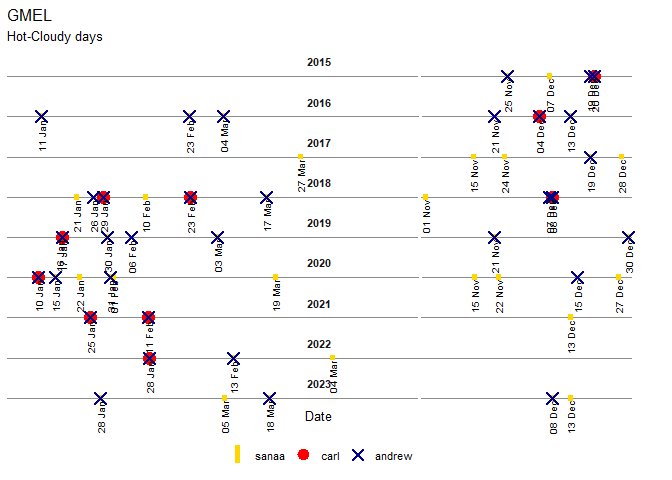

In [ ]:
plot_region_cut_calendar("GMEL", gap_days = 1)

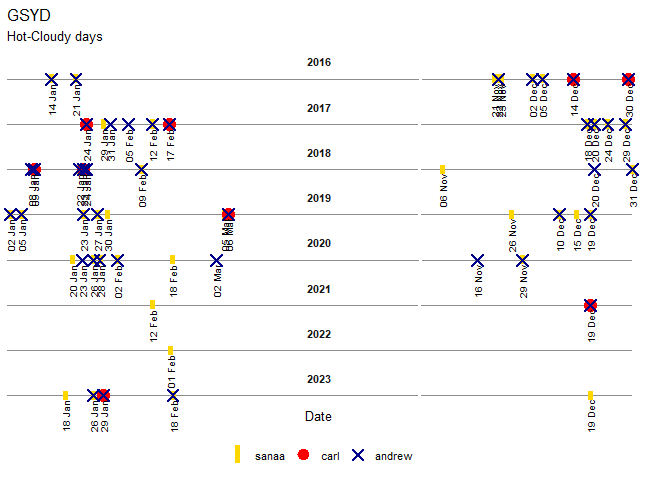

In [ ]:
plot_region_cut_calendar("GSYD", gap_days = 1)

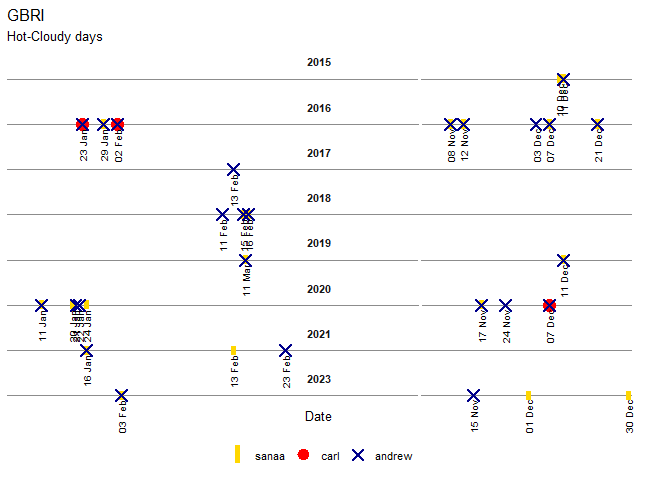

In [ ]:
plot_region_cut_calendar("GBRI", gap_days = 1)

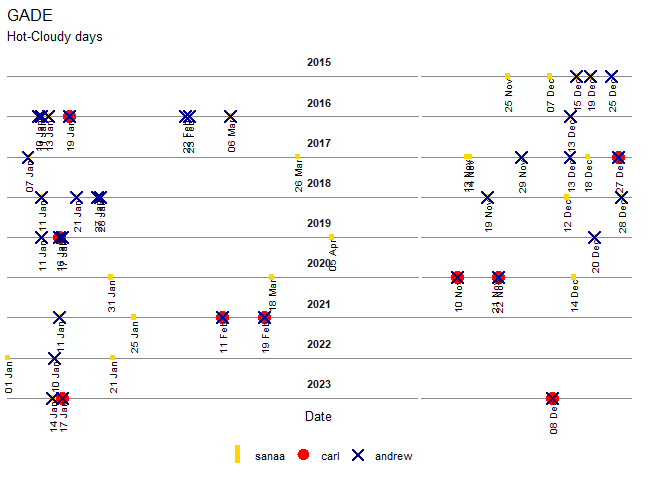

In [ ]:
plot_region_cut_calendar("GADE", gap_days = 1)

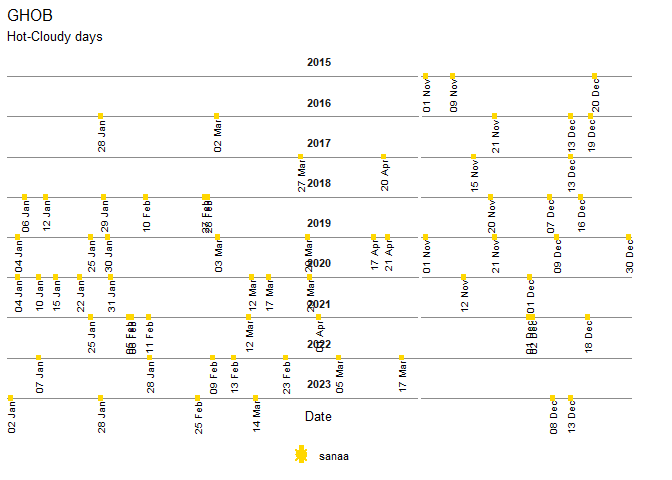

In [ ]:
plot_region_cut_calendar("GHOB", gap_days = 1)

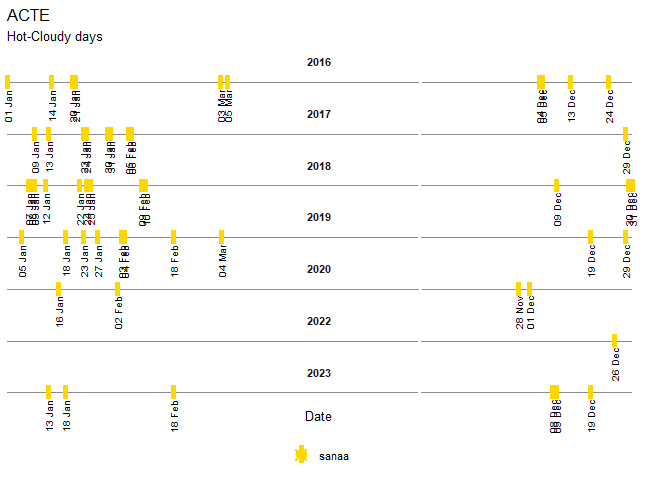

In [ ]:
plot_region_cut_calendar("ACTE", gap_days = 1)

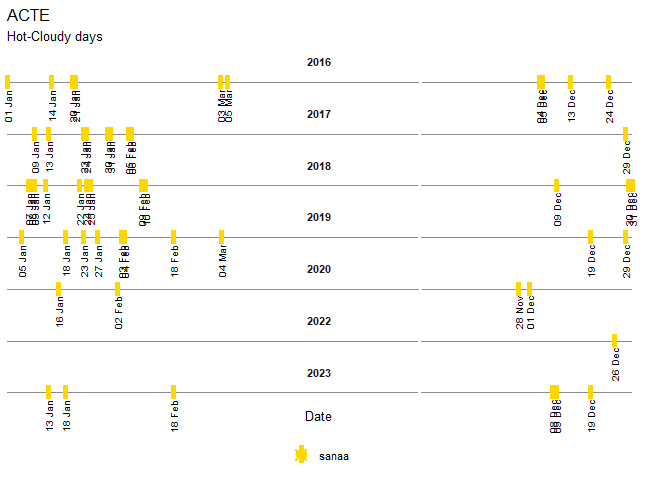

In [ ]:
regions <- c("GSYD", "GMEL", "GBRI", "GADE", "GHOB", "ACTE")
plot_region_cut_calendar("ACTE", gap_days = 1)

In [ ]:
out_dir <- '... path to /plots ...'

# make sure directory exists
if (!dir.exists(out_dir)) dir.create(out_dir, recursive = TRUE)

for (reg in unique(long$region)) {
  p <- plot_region_cut_calendar(reg, gap_days = 1)

  out_file <- file.path(
    out_dir,
    paste0("hot_cloudy_days_csi0p5_t90p_", reg, ".png")
  )

  ggsave(
    filename = out_file,
    plot = p,
    width = 38,
    height = 18,
    units = "cm",
    bg = "white"
  )
}

Duplicated `override.aes` is ignored.
Duplicated `override.aes` is ignored.
Duplicated `override.aes` is ignored.
Duplicated `override.aes` is ignored.
Duplicated `override.aes` is ignored.